# Práctica guiada: Procesamiento digital de imágenes

Esta práctica funciona como puente entre los cuadernos conceptuales y el laboratorio aplicado. La propuesta es que completes código, pruebes variantes y expliques con tus palabras qué decisiones tomaste.

## Objetivos

- Recuperar ideas de color, canales, bordes e intensidad.
- Practicar lectura de imágenes con `OpenCV`.
- Resolver consignas breves con andamiaje.
- Prepararte para el laboratorio de segmentación y la actividad integradora.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski


def mostrar_imagenes(imagenes, titulos, cmap=None, figsize=(14, 4)):
    fig, axes = plt.subplots(1, len(imagenes), figsize=figsize)
    if len(imagenes) == 1:
        axes = [axes]

    for ax, imagen, titulo in zip(axes, imagenes, titulos):
        if imagen.ndim == 2:
            ax.imshow(imagen, cmap=cmap or "gray")
        else:
            ax.imshow(imagen)
        ax.set_title(titulo)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def segmentar_por_umbral(imagen, umbral):
    mascara = np.zeros_like(imagen, dtype=np.uint8)
    mascara[imagen > umbral] = 255
    return mascara


In [2]:
base = Path(".")

cv2.imwrite(str(base / "paisaje.png"), cv2.cvtColor(ski.data.astronaut(), cv2.COLOR_RGB2BGR))
cv2.imwrite(str(base / "texto.png"), ski.data.page())
cv2.imwrite(str(base / "monedas.png"), ski.data.coins())

print("Archivos de práctica listos: paisaje.png, texto.png y monedas.png")


Archivos de práctica listos: paisaje.png, texto.png y monedas.png


## Ejercicio 1: Color y canales

Completá los pasos.

1. Cargá `paisaje.png` con `OpenCV`.
2. Convertí la imagen a `RGB`.
3. Extraé los tres canales.
4. Mostrá la imagen original y los canales por separado.
5. Escribí una observación breve sobre qué zonas se destacan en cada canal.


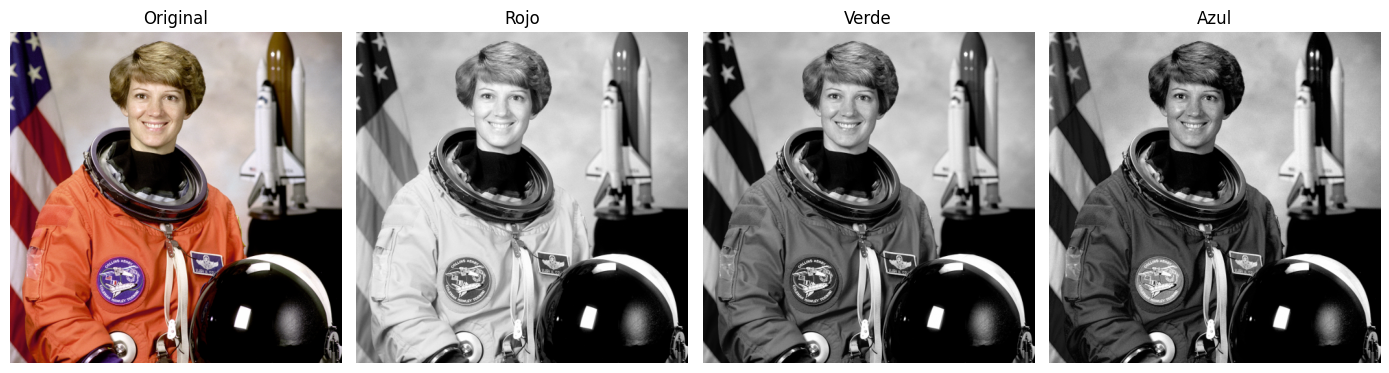

In [4]:
# 1. Cargar la imagen
img_bgr = cv2.imread("paisaje.png")
if img_bgr is None:
    raise FileNotFoundError("No se encontró la imagen 'paisaje.png'")
# 2. Convertirla a RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Extraer canales
canal_rojo = img_rgb[:, :, 0]
canal_verde = img_rgb[:, :, 1]
canal_azul = img_rgb[:, :, 2]

# 4. Visualizar resultados
mostrar_imagenes(
    [img_rgb, canal_rojo, canal_verde, canal_azul],
    ["Original", "Rojo", "Verde", "Azul"],
)


In [7]:
# Escribí acá tu observación sobre los canales.
# ¿Qué zonas aparecen más brillantes en cada uno?

observacion_canales = """
¿Qué zonas aparecen más brillantes en cada uno?
Canal Rojo: zonas más brillantes son aquellas con tonos rojizos o anaranjados
(atardeceres, flores rojas, ladrillos, etc.).
Canal Verde: zonas más brillantes corresponden a áreas vegetacionadas
(árboles, pasto) y tonos amarillentos.
Canal Azul: zonas más brillantes son regiones con tonos azules
(cielo, agua, sombras) y áreas de la imagen con tonalidades frías"""
print(observacion_canales)



¿Qué zonas aparecen más brillantes en cada uno?
Canal Rojo: zonas más brillantes son aquellas con tonos rojizos o anaranjados
(atardeceres, flores rojas, ladrillos, etc.).
Canal Verde: zonas más brillantes corresponden a áreas vegetacionadas
(árboles, pasto) y tonos amarillentos.
Canal Azul: zonas más brillantes son regiones con tonos azules
(cielo, agua, sombras) y áreas de la imagen con tonalidades frías


## Ejercicio 2: Recorte y redimensionado

1. Definí una región de interés de `100 x 100` píxeles dentro de `paisaje.png`.
2. Redimensioná ese recorte a `220 x 220` píxeles.
3. Armá un mosaico `2 x 2` con el recorte redimensionado.
4. Explicá, con una frase, la diferencia entre recortar y redimensionar.


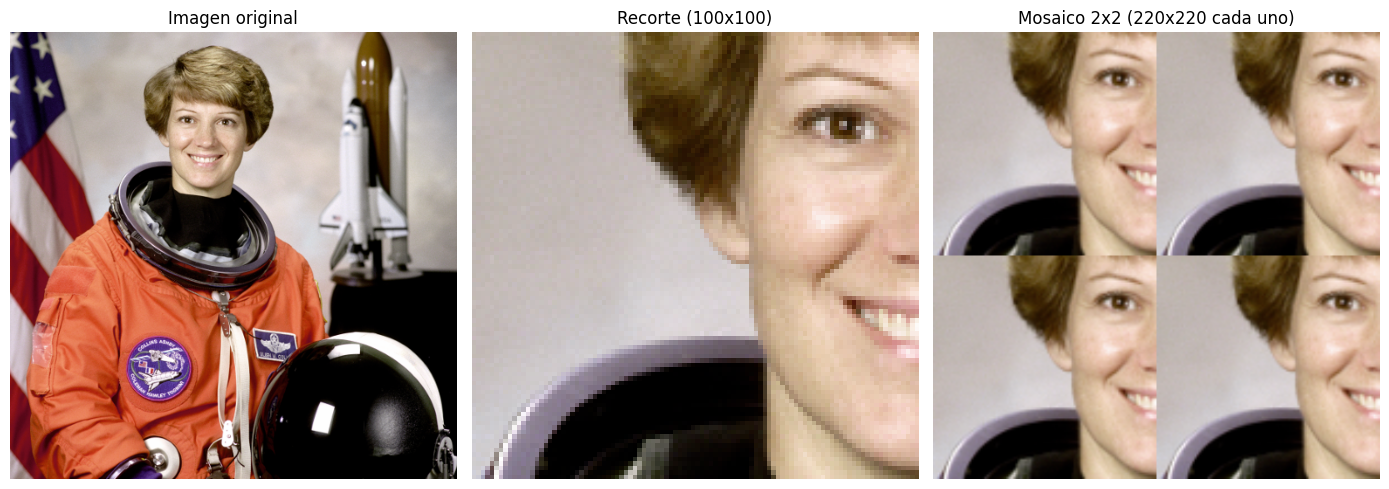

El recorte selecciona una subregión sin cambiar su resolución, mientras que el redimensionado altera el número total de píxeles mediante interpolación.


In [11]:
# 2. Definir una región de interés de 100 x 100 píxeles
# Usamos las coordenadas proporcionadas pero ajustamos a 100x100: de 80:180 y 120:220
recorte = img_rgb[80:180, 120:220]  # 100x100 píxeles

# 3. Redimensionar ese recorte a 220 x 220 píxeles
recorte_grande = cv2.resize(recorte, (220, 220))

# 4. Armá un mosaico 2 x 2 con el recorte redimensionado
mosaico = np.tile(recorte_grande, (2, 2, 1))

# Mostrar resultados
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(recorte)
axes[1].set_title("Recorte (100x100)")
axes[1].axis("off")

axes[2].imshow(mosaico)
axes[2].set_title("Mosaico 2x2 (220x220 cada uno)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# 5. Explicar, con una frase, la diferencia entre recortar y redimensionar
print(
    "El recorte selecciona una subregión sin cambiar su resolución, mientras que el redimensionado altera el número total de píxeles mediante interpolación."
)


In [10]:
# Explicación breve.
explicacion_geometria = """Explicación geométrica:

Recorte (cropping): Selecciona un subconjunto de píxeles definiendo un rectángulo en el plano de coordenadas de la imagen. 
No altera la resolución ni la escala de los píxeles seleccionados. 
Geométricamente, es una operación de proyección sobre un subconjunto del dominio original.

Redimensionado (resize): Cambia el número total de píxeles mediante interpolación (ej. bilineal, nearest). 
Geométricamente, aplica una transformación de escala (y posiblemente traslación) al plano de coordenadas, 
mapeando cada píxel de la imagen de salida a una ubicación (posiblemente fraccionaria) en la imagen de entrada y calculando su valor mediante interpolación. 
Esto altera la densidad de muestreo y el tamaño físico relativo de los objetos en la imagen. """
print(explicacion_geometria)


Explicación geométrica:

Recorte (cropping): Selecciona un subconjunto de píxeles definiendo un rectángulo en el plano de coordenadas de la imagen. 
No altera la resolución ni la escala de los píxeles seleccionados; simplemente descarta los fuera del rectángulo. 
Geométricamente, es una operación de proyección sobre un subconjunto del dominio original.

Redimensionado (resize): Cambia el número total de píxeles mediante interpolación (ej. bilineal, nearest). 
Geométricamente, aplica una transformación de escala (y posiblemente traslación) al plano de coordenadas, 
mapeando cada píxel de la imagen de salida a una ubicación (posiblemente fraccionaria) en la imagen de entrada y calculando su valor mediante interpolación. 
Esto altera la densidad de muestreo y el tamaño físico relativo de los objetos en la imagen. 


## Ejercicio 3: Bordes y umbralización

1. Cargá `texto.png` en escala de grises.
2. Aplicá `Canny` con dos pares de umbrales distintos.
3. Cargá `monedas.png` en escala de grises.
4. Segmentá la imagen de monedas con al menos dos umbrales.
5. Compará los resultados y explicá cuál te parece más útil.


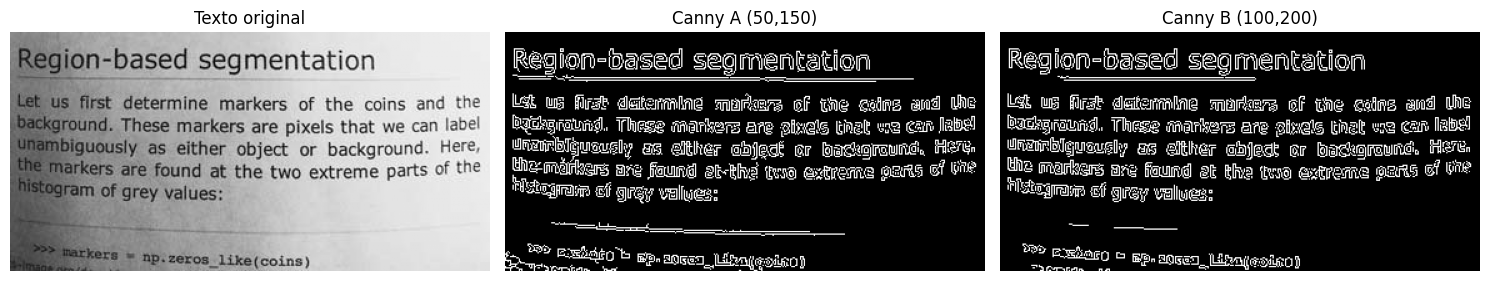

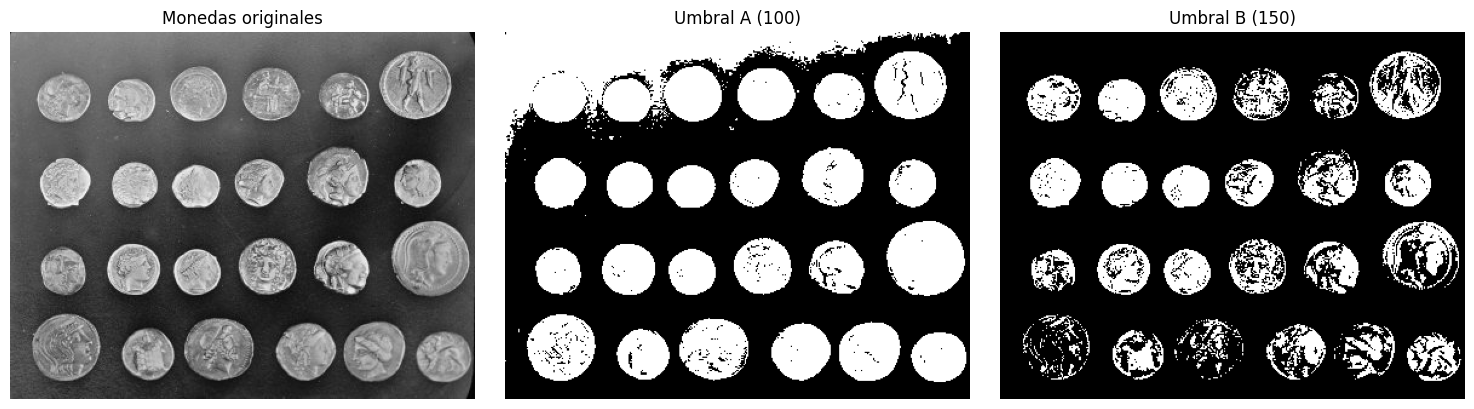

Comparación de resultados:
- Para el texto: Canny A (50,150) detecta más bordes finos y detalles de las letras, mientras que Canny B (100,200) solo detecta bordes más fuertes, posiblemente perdiendo trazos finos.
- Para las monedas: Umbral A (100) puede segmentar más áreas pero también incluir ruido o fondo; Umbral B (150) suele dar una segmentación más limpia de las monedas al separarlas mejor del fondo.

Conclusión:
Para detección de bordes en texto, un umbral bajo en Canny es más útil para capturar detalles. Para segmentación de monedas, un umbral intermedio-alto (como 150) suele ser más útil para obtener regiones homogéneas y reducir falsos positivos.


In [16]:
# 1. Cargar texto.png en escala de grises
img_texto = cv2.imread("texto.png", cv2.IMREAD_GRAYSCALE)
if img_texto is None:
    raise FileNotFoundError("No se encontró 'texto.png'")

# 2. Aplicar Canny con dos pares de umbrales distintos
canny_a = cv2.Canny(img_texto, 50, 150)  # Umbrales bajos
canny_b = cv2.Canny(img_texto, 100, 200)  # Umbrales altos

mostrar_imagenes(
    [img_texto, canny_a, canny_b],
    ["Texto original", "Canny A (50,150)", "Canny B (100,200)"],
    figsize=(15, 4),
)

# 3. Cargar monedas.png en escala de grises
img_monedas = cv2.imread("monedas.png", cv2.IMREAD_GRAYSCALE)
if img_monedas is None:
    raise FileNotFoundError("No se encontró 'monedas.png'")

# 4. Segmentar la imagen de monedas con al menos dos umbrales
seg_a = segmentar_por_umbral(img_monedas, 100)  # Umbral bajo
seg_b = segmentar_por_umbral(img_monedas, 150)  # Umbral alto

mostrar_imagenes(
    [img_monedas, seg_a, seg_b],
    ["Monedas originales", "Umbral A (100)", "Umbral B (150)"],
    figsize=(15, 4),
)
# 5. Comparar resultados y explicar cuál es más útil
print("Comparación de resultados:")
print(
    "- Para el texto: Canny A (50,150) detecta más bordes finos y detalles de las letras, mientras que Canny B (100,200) solo detecta bordes más fuertes, "
    "posiblemente perdiendo trazos finos."
)
print(
    "- Para las monedas: Umbral A (100) puede segmentar más áreas pero también incluir ruido o fondo; Umbral B (150) suele dar una segmentación más limpia "
    "de las monedas al separarlas mejor del fondo."
)
print("\nConclusión:")
print(
    "Para detección de bordes en texto, un umbral bajo en Canny es más útil para capturar detalles. Para segmentación de monedas, un umbral intermedio-alto (como 150) "
    "suele ser más útil para obtener regiones homogéneas y reducir falsos positivos."
)

## Cierre breve

Antes de pasar al laboratorio, revisá si podés responder estas preguntas:

- ¿cuándo conviene mirar canales por separado?

Conviene mirar canales por separado cuando se necesita aislar información de color específica (ej. detectar objetos rojos, analizar vegetación en verde o cielo/agua en azul) o cuando cada canal representa una característica distinta (multiespectral, corrección de color).
- ¿qué cambia al modificar los umbrales de `Canny`?

Al aumentar los umbrales de Canny, el detector se vuelve más estricto: detecta solo bordes fuertes, reduciendo ruido pero perdiendo detalles finos. Al disminuirlos, detecta más bordes incluyendo débiles, pero también aumenta falsos positivos por ruido.
- ¿por qué una segmentación por umbral puede funcionar bien en una imagen y mal en otra?

La segmentación por umbral asume un contraste bimodal claro entre objeto y fondo. Funciona bien cuando la iluminación es uniforme y hay separación de intensidades; falla con iluminación no uniforme, solapamiento de histogramas o múltiples objetos con intensidades similares, donde un umbral global no basta.

Si todavía dudás en alguna, volvé a los cuadernos anteriores y recuperá las ideas centrales.
